# Analyse Factorielle des Correspondances – Élections Présidentielles 2012

---

| | |
|---|---|
| **Étudiant** | ADEM YENGUI |
| **Titre** | Analyse Factorielle des Correspondances – Élections Présidentielles 2012 |
| **Objectif** | Application de l'AFC sur les résultats des élections présidentielles françaises de 2012 par région |
| **Données** | `resultats_presidentielles_2012.csv` – 23 régions × 10 candidats |

---

## Introduction

L'**Analyse Factorielle des Correspondances (AFC)** est une méthode d'analyse exploratoire multivariée destinée à étudier les relations entre deux variables qualitatives représentées sous la forme d'un tableau de contingence. Elle permet de visualiser simultanément les profils-lignes et les profils-colonnes dans un espace factoriel de faible dimension.

Dans ce travail, nous cherchons à analyser les associations entre les **régions françaises** et les **candidats à l'élection présidentielle de 2012**, afin d'identifier quelles régions ont tendance à voter pour quels candidats.

---
## Partie 1 – Chargement et Exploration des Données

In [ ]:
# ─── Imports ───────────────────────────────────────────────────────────────────
!pip install prince
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
import prince
import warnings
warnings.filterwarnings('ignore')

# Aesthetic settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 5.9 MB/s eta 0:00:00
Libraries loaded successfully.


In [ ]:
# ─── Chargement du fichier CSV ─────────────────────────────────────────────────
df_raw = pd.read_csv('data.csv', sep=None, engine='python')
print(f'Dimensions du jeu de données : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes\n')
df_raw

Dimensions du jeu de données : 23 lignes × 12 colonnes



,Region,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade,Blancs_Nuls
0,Alsace,191282,326313,219251,116115,72376,27168,18681,10817,6387,2977,19825
1,Aquitaine,593891,465683,296210,204805,231951,45067,31199,30281,9114,4371,36540
2,Auvergne,252117,192229,139868,81816,104730,15348,15276,10333,5509,2010,19031
3,Bourgogne,262816,250202,191148,81986,97185,17077,19101,11192,5937,2318,19160
4,Bretagne,628421,508072,262102,224902,217923,58396,35587,26693,12593,5085,36169
5,Centre,385182,403455,280094,137170,151969,26314,30608,17609,9827,3752,29194
6,Champ-Ard,178914,206171,172783,62093,62184,10150,14993,8611,4990,1752,12621
7,Corse,39029,50493,39210,8045,15843,3762,1728,1870,502,337,2919
8,Fr-Comte,172644,177701,141969,58233,73946,14379,13221,8459,4615,1797,14590
9,Ile-de-Fr,1695345,1549965,655835,492062,632181,144338,92469,44554,20129,13411,86766


In [ ]:
# ─── Informations générales ────────────────────────────────────────────────────
print('=== df.info() ===')
df_raw.info()
print('\n=== Statistiques descriptives ===')
df_raw.describe()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Region         23 non-null     object
 1   Hollande       23 non-null     int64 
 2   Sarkozy        23 non-null     int64 
 3   Le_Pen         23 non-null     int64 
 4   Bayrou         23 non-null     int64 
 5   Melenchon      23 non-null     int64 
 6   Joly           23 non-null     int64 
 7   Dupond_Aignan  23 non-null     int64 
 8   Poutou         23 non-null     int64 
 9   Arthaud        23 non-null     int64 
 10  Cheminade      23 non-null     int64 
 11  Blancs_Nuls    23 non-null     int64 
dtypes: int64(11), object(1)
memory usage: 2.3+ KB

=== Statistiques descriptives ===


,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade,Blancs_Nuls
count,2.300000e+01,2.300000e+01,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,4.338863e+05,4.174149e+05,308024.347826,145713.347826,172009.217391,35229.217391,27887.913043,17415.608696,8387.782609,3750.043478,30379.434783
std,3.314601e+05,3.295549e+05,203145.929653,113609.928412,136105.129253,32370.225573,19971.121498,10151.495715,4735.900413,2776.487259,18905.307056
min,3.902900e+04,5.049300e+04,39210.000000,8045.000000,15843.000000,3762.000000,1728.000000,1870.000000,502.000000,337.000000,2919.000000
25%,2.474115e+05,2.498375e+05,161792.000000,81901.000000,81005.000000,16168.000000,16978.500000,10575.000000,5723.000000,2281.500000,19095.500000
50%,3.320030e+05,3.263130e+05,266067.000000,116115.000000,126333.000000,22749.000000,22168.000000,15347.000000,7027.000000,3117.000000,24321.000000
75%,5.973175e+05,4.868775e+05,336338.500000,161225.000000,223603.000000,44915.000000,33239.500000,22211.000000,9631.000000,4272.000000,39033.500000
max,1.695345e+06,1.549965e+06,740116.000000,492062.000000,632181.000000,144338.000000,92469.000000,44554.000000,20129.000000,13411.000000,86766.000000


### 1.1 Identification des Variables Qualitatives

Le jeu de données est un **tableau de contingence** où :
- **Variable 1 (lignes)** : `Région` — 23 modalités (régions françaises)
- **Variable 2 (colonnes)** : `Candidat` — 10 candidats à l'élection présidentielle
- **Valeurs** : effectifs bruts (nombre de votes)

La colonne `Blancs_Nuls` est exclue de l'analyse car elle ne correspond pas à un candidat.

> **Note** : En AFC, on travaille exclusivement avec un tableau de contingence croisant deux variables qualitatives.

In [ ]:
# ─── Construction du tableau de contingence ────────────────────────────────────
# On retire 'Blancs_Nuls' (non-candidat) et on indexe par Région
contingency = df_raw.set_index('Region').drop(columns=['Blancs_Nuls'])

print('=== Tableau de Contingence (effectifs bruts) ===')
print(f'Dimensions : {contingency.shape[0]} régions × {contingency.shape[1]} candidats\n')
contingency

=== Tableau de Contingence (effectifs bruts) ===
Dimensions : 23 régions × 10 candidats



,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade
Region,,,,,,,,,,
Alsace,191282,326313,219251,116115,72376,27168,18681,10817,6387,2977
Aquitaine,593891,465683,296210,204805,231951,45067,31199,30281,9114,4371
Auvergne,252117,192229,139868,81816,104730,15348,15276,10333,5509,2010
Bourgogne,262816,250202,191148,81986,97185,17077,19101,11192,5937,2318
Bretagne,628421,508072,262102,224902,217923,58396,35587,26693,12593,5085
Centre,385182,403455,280094,137170,151969,26314,30608,17609,9827,3752
Champ-Ard,178914,206171,172783,62093,62184,10150,14993,8611,4990,1752
Corse,39029,50493,39210,8045,15843,3762,1728,1870,502,337
Fr-Comte,172644,177701,141969,58233,73946,14379,13221,8459,4615,1797


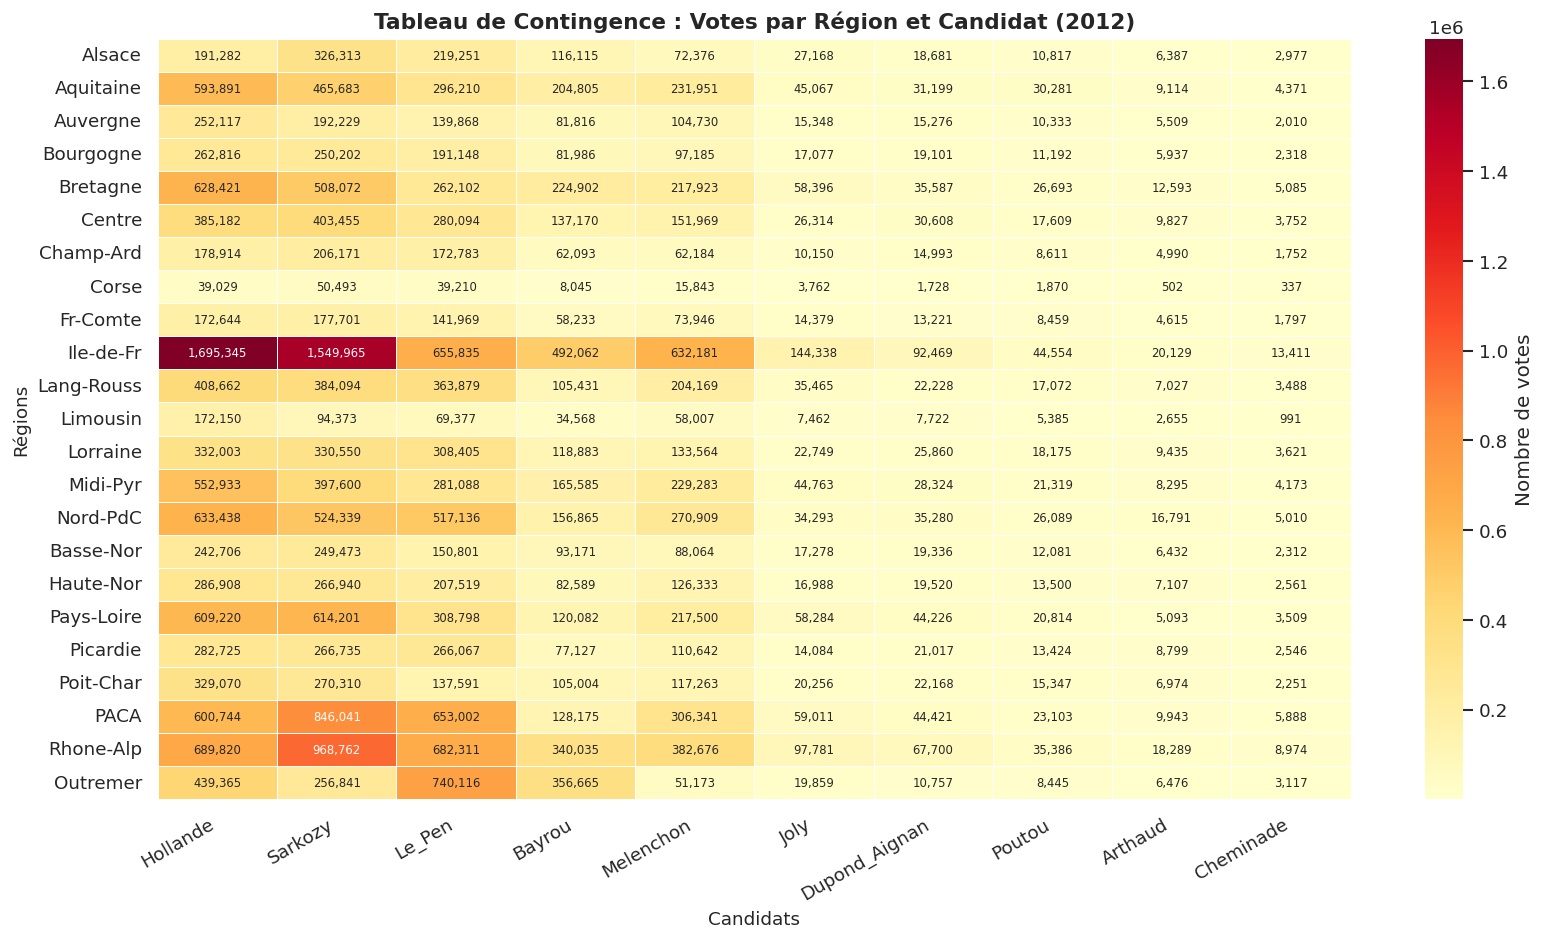

In [ ]:
# ─── Heatmap du tableau de contingence ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(contingency, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.3, ax=ax,
            annot_kws={'size': 7},
            cbar_kws={'label': 'Nombre de votes'})
ax.set_title('Tableau de Contingence : Votes par Région et Candidat (2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Candidats', fontsize=11)
ax.set_ylabel('Régions', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Partie 2 – Test d'Indépendance du Chi-deux (χ²)

Avant d'appliquer l'AFC, il est nécessaire de tester statistiquement si les deux variables (Région et Candidat) sont **indépendantes** ou **associées**. Le test du Chi-deux de Pearson est la procédure standard.

**Hypothèses :**
- $H_0$ : Les variables Région et Candidat sont **indépendantes** (aucune association)
- $H_1$ : Les variables Région et Candidat sont **dépendantes** (association significative)

**Statistique de test :**
$$\chi^2 = \sum_{i=1}^{I} \sum_{j=1}^{J} \frac{(n_{ij} - \hat{n}_{ij})^2}{\hat{n}_{ij}}, \quad \hat{n}_{ij} = \frac{n_{i.} \cdot n_{.j}}{n}$$

avec $n_{i.}$ le total de la ligne $i$, $n_{.j}$ le total de la colonne $j$, et $n$ le grand total.

In [ ]:
# ─── Test d'indépendance Chi-deux ─────────────────────────────────────────────
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

alpha = 0.05
from scipy.stats import chi2 as chi2_dist
chi2_critical = chi2_dist.ppf(1 - alpha, df=dof)

print('=' * 55)
print('    TEST D\'INDÉPENDANCE DU CHI-DEUX (χ²)')
print('=' * 55)
print(f'  Statistique χ²     : {chi2_stat:,.4f}')
print(f'  p-value            : {p_value:.2e}')
print(f'  Degrés de liberté  : {dof}')
print(f'  Valeur critique    : {chi2_critical:.4f}  (α = {alpha})')
print('-' * 55)
if p_value < alpha:
    print(f'  → Décision : REJET de H₀ (p < {alpha})')
    print('  → Conclusion : Les variables Région et Candidat')
    print('    sont SIGNIFICATIVEMENT DÉPENDANTES.')
    print('    L\'AFC est donc JUSTIFIÉE.')
else:
    print(f'  → Décision : Non-rejet de H₀ (p ≥ {alpha})')
    print('  → Conclusion : Indépendance non rejetée.')
print('=' * 55)

    TEST D'INDÉPENDANCE DU CHI-DEUX (χ²)
  Statistique χ²     : 1,801,032.0082
  p-value            : 0.00e+00
  Degrés de liberté  : 198
  Valeur critique    : 231.8292  (α = 0.05)
-------------------------------------------------------
  → Décision : REJET de H₀ (p < 0.05)
  → Conclusion : Les variables Région et Candidat
    sont SIGNIFICATIVEMENT DÉPENDANTES.
    L'AFC est donc JUSTIFIÉE.


In [ ]:
# ─── Effectifs théoriques (attendus sous H₀) ──────────────────────────────────
expected_df = pd.DataFrame(expected,
                           index=contingency.index,
                           columns=contingency.columns)
print('=== Effectifs Théoriques sous H₀ (5 premières lignes) ===')
expected_df.round(1).head()

=== Effectifs Théoriques sous H₀ (5 premières lignes) ===


,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade
Region,,,,,,,,,,
Alsace,274024.0,263621.4,194535.0,92026.3,108633.6,22249.3,17612.8,10999.0,5297.4,2368.4
Aquitaine,528654.5,508585.4,375302.1,177539.6,209579.0,42923.9,33979.1,21219.5,10219.8,4569.1
Auvergne,226445.2,217848.8,160757.9,76047.8,89771.6,18386.1,14554.7,9089.2,4377.6,1957.1
Bourgogne,259538.7,249686.0,184251.6,87161.7,102891.1,21073.1,16681.8,10417.5,5017.3,2243.2
Bretagne,547229.8,526455.6,388489.1,183777.8,216942.9,44432.1,35173.0,21965.1,10578.9,4729.7


### Interprétation

La valeur du $\chi^2$ est très élevée et la p-value est extrêmement petite ($\ll 0.001$), ce qui conduit au **rejet de l'hypothèse nulle d'indépendance**. Les régions françaises et les candidats sont donc **statistiquement associés** : les préférences de vote varient significativement d'une région à l'autre. L'AFC est pleinement justifiée pour explorer et visualiser ces associations.

---
## Partie 3 – Calcul Manuel des Éléments de l'AFC

### 3.1 Fréquences Relatives (Tableau des Probabilités)

On divise chaque cellule $n_{ij}$ par le grand total $n$ :
$$f_{ij} = \frac{n_{ij}}{n}$$

In [ ]:
# ─── Grand total et fréquences relatives ──────────────────────────────────────
N = contingency.values.sum()  # Grand total n
F = contingency / N           # Matrice des fréquences relatives f_ij

print(f'Grand total n = {N:,}')
print()
print('=== Matrice des Fréquences Relatives f_ij ===')
F.round(6)

Grand total n = 36,103,530

=== Matrice des Fréquences Relatives f_ij ===


,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade
Region,,,,,,,,,,
Alsace,0.005298,0.009038,0.006073,0.003216,0.002005,0.000753,0.000517,0.000300,0.000177,0.000082
Aquitaine,0.016450,0.012899,0.008204,0.005673,0.006425,0.001248,0.000864,0.000839,0.000252,0.000121
Auvergne,0.006983,0.005324,0.003874,0.002266,0.002901,0.000425,0.000423,0.000286,0.000153,0.000056
Bourgogne,0.007280,0.006930,0.005294,0.002271,0.002692,0.000473,0.000529,0.000310,0.000164,0.000064
Bretagne,0.017406,0.014073,0.007260,0.006229,0.006036,0.001617,0.000986,0.000739,0.000349,0.000141
Centre,0.010669,0.011175,0.007758,0.003799,0.004209,0.000729,0.000848,0.000488,0.000272,0.000104
Champ-Ard,0.004956,0.005711,0.004786,0.001720,0.001722,0.000281,0.000415,0.000239,0.000138,0.000049
Corse,0.001081,0.001399,0.001086,0.000223,0.000439,0.000104,0.000048,0.000052,0.000014,0.000009
Fr-Comte,0.004782,0.004922,0.003932,0.001613,0.002048,0.000398,0.000366,0.000234,0.000128,0.000050


### 3.2 Masses Lignes et Masses Colonnes

- **Masse de la ligne $i$** (fréquence marginale) : $f_{i\bullet} = \sum_{j} f_{ij}$
- **Masse de la colonne $j$** (fréquence marginale) : $f_{\bullet j} = \sum_{i} f_{ij}$

In [ ]:
# ─── Masses lignes et colonnes ────────────────────────────────────────────────
fi_dot = F.sum(axis=1)   # f_i. : masses lignes
f_dot_j = F.sum(axis=0)  # f_.j : masses colonnes

print('=== Masses Lignes (f_i.) ===')
fi_df = pd.DataFrame({'Masse f_i.': fi_dot, 'Effectifs marginaux n_i.': contingency.sum(axis=1)})
fi_df['% du total'] = (fi_df['Masse f_i.'] * 100).round(3)
print(fi_df.round(6).to_string())

print('\n=== Masses Colonnes (f_.j) ===')
fj_df = pd.DataFrame({'Masse f_.j': f_dot_j, 'Effectifs marginaux n_.j': contingency.sum(axis=0)})
fj_df['% du total'] = (fj_df['Masse f_.j'] * 100).round(3)
print(fj_df.round(6).to_string())

print(f'\nVérification : Σ f_i. = {fi_dot.sum():.6f} | Σ f_.j = {f_dot_j.sum():.6f} (doit être ≈ 1)')

=== Masses Lignes (f_i.) ===
            Masse f_i.  Effectifs marginaux n_i.  % du total
Region                                                      
Alsace        0.027459                    991367       2.746
Aquitaine     0.052975                   1912572       5.297
Auvergne      0.022691                    819236       2.269
Bourgogne     0.026007                    938962       2.601
Bretagne      0.054836                   1979774       5.484
Centre        0.040051                   1445980       4.005
Champ-Ard     0.020016                    722641       2.002
Corse         0.004454                    160819       0.445
Fr-Comte      0.018474                    666964       1.847
Ile-de-Fr     0.147916                   5340289      14.792
Lang-Rouss    0.042974                   1551515       4.297
Limousin      0.012539                    452690       1.254
Lorraine      0.036097                   1303245       3.610
Midi-Pyr      0.048011                   1733363       4

### 3.3 Profils Lignes et Barycentre des Colonnes

Le **profil-ligne** de la région $i$ est le vecteur des fréquences relatives *conditionnelles* à la ligne $i$ :
$$p_{ij} = \frac{f_{ij}}{f_{i\bullet}} \quad \Rightarrow \quad \sum_j p_{ij} = 1$$

Le **barycentre des profils-lignes** (pondéré par les masses) coïncide avec le profil-colonne moyen :
$$\bar{p}_{\bullet j} = \sum_i f_{i\bullet} \cdot p_{ij} = f_{\bullet j}$$

In [ ]:
# ─── Profils Lignes ───────────────────────────────────────────────────────────
# p_ij = f_ij / f_i.  (chaque ligne divisée par sa masse)
row_profiles = F.div(fi_dot, axis=0)  # shape: (I, J)

print('=== Profils Lignes (p_ij = f_ij / f_i.) ===')
print('Chaque ligne somme à 1 : représente la distribution des votes d\'une région entre les candidats.')
print()
display_rp = row_profiles.copy()
display_rp['TOTAL'] = display_rp.sum(axis=1)
display_rp.round(4)

=== Profils Lignes (p_ij = f_ij / f_i.) ===
Chaque ligne somme à 1 : représente la distribution des votes d'une région entre les candidats.



,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade,TOTAL
Region,,,,,,,,,,,
Alsace,0.1929,0.3292,0.2212,0.1171,0.0730,0.0274,0.0188,0.0109,0.0064,0.0030,1.0
Aquitaine,0.3105,0.2435,0.1549,0.1071,0.1213,0.0236,0.0163,0.0158,0.0048,0.0023,1.0
Auvergne,0.3077,0.2346,0.1707,0.0999,0.1278,0.0187,0.0186,0.0126,0.0067,0.0025,1.0
Bourgogne,0.2799,0.2665,0.2036,0.0873,0.1035,0.0182,0.0203,0.0119,0.0063,0.0025,1.0
Bretagne,0.3174,0.2566,0.1324,0.1136,0.1101,0.0295,0.0180,0.0135,0.0064,0.0026,1.0
Centre,0.2664,0.2790,0.1937,0.0949,0.1051,0.0182,0.0212,0.0122,0.0068,0.0026,1.0
Champ-Ard,0.2476,0.2853,0.2391,0.0859,0.0861,0.0140,0.0207,0.0119,0.0069,0.0024,1.0
Corse,0.2427,0.3140,0.2438,0.0500,0.0985,0.0234,0.0107,0.0116,0.0031,0.0021,1.0
Fr-Comte,0.2589,0.2664,0.2129,0.0873,0.1109,0.0216,0.0198,0.0127,0.0069,0.0027,1.0


In [ ]:
# ─── Barycentre des Colonnes (= profil-colonne moyen) ─────────────────────────
barycentre_cols = row_profiles.mul(fi_dot, axis=0).sum(axis=0)  # Σ f_i. * p_ij
print('=== Barycentre des Profils-Lignes (= masses colonnes f_.j) ===')
comparison = pd.DataFrame({
    'Barycentre Σ(f_i. * p_ij)': barycentre_cols,
    'Masse colonne f_.j': f_dot_j,
    'Égalité': np.isclose(barycentre_cols, f_dot_j)
})
print(comparison.round(8).to_string())
print('\n→ Le barycentre des profils-lignes (pondéré par f_i.) est bien égal au profil moyen f_.j.')

=== Barycentre des Profils-Lignes (= masses colonnes f_.j) ===
               Barycentre Σ(f_i. * p_ij)  Masse colonne f_.j  Égalité
Hollande                        0.276410            0.276410     True
Sarkozy                         0.265917            0.265917     True
Le_Pen                          0.196229            0.196229     True
Bayrou                          0.092828            0.092828     True
Melenchon                       0.109580            0.109580     True
Joly                            0.022443            0.022443     True
Dupond_Aignan                   0.017766            0.017766     True
Poutou                          0.011095            0.011095     True
Arthaud                         0.005343            0.005343     True
Cheminade                       0.002389            0.002389     True

→ Le barycentre des profils-lignes (pondéré par f_i.) est bien égal au profil moyen f_.j.


### 3.4 Profils Colonnes et Barycentre des Lignes

Le **profil-colonne** du candidat $j$ :
$$q_{ij} = \frac{f_{ij}}{f_{\bullet j}} \quad \Rightarrow \quad \sum_i q_{ij} = 1$$

In [ ]:
# ─── Profils Colonnes ─────────────────────────────────────────────────────────
# q_ij = f_ij / f_.j  (chaque colonne divisée par sa masse)
col_profiles = F.div(f_dot_j, axis=1)  # shape: (I, J)

print('=== Profils Colonnes (q_ij = f_ij / f_.j) ===')
print('Chaque colonne somme à 1 : représente la répartition géographique des votes pour un candidat.')
print()
display_cp = col_profiles.copy()
display_cp['TOTAL'] = display_cp.sum(axis=1)
display_cp.round(4)

=== Profils Colonnes (q_ij = f_ij / f_.j) ===
Chaque colonne somme à 1 : représente la répartition géographique des votes pour un candidat.



,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade,TOTAL
Region,,,,,,,,,,,
Alsace,0.0192,0.0340,0.0309,0.0346,0.0183,0.0335,0.0291,0.0270,0.0331,0.0345,0.2943
Aquitaine,0.0595,0.0485,0.0418,0.0611,0.0586,0.0556,0.0486,0.0756,0.0472,0.0507,0.5473
Auvergne,0.0253,0.0200,0.0197,0.0244,0.0265,0.0189,0.0238,0.0258,0.0286,0.0233,0.2363
Bourgogne,0.0263,0.0261,0.0270,0.0245,0.0246,0.0211,0.0298,0.0279,0.0308,0.0269,0.2649
Bretagne,0.0630,0.0529,0.0370,0.0671,0.0551,0.0721,0.0555,0.0666,0.0653,0.0590,0.5935
Centre,0.0386,0.0420,0.0395,0.0409,0.0384,0.0325,0.0477,0.0440,0.0509,0.0435,0.4181
Champ-Ard,0.0179,0.0215,0.0244,0.0185,0.0157,0.0125,0.0234,0.0215,0.0259,0.0203,0.2016
Corse,0.0039,0.0053,0.0055,0.0024,0.0040,0.0046,0.0027,0.0047,0.0026,0.0039,0.0396
Fr-Comte,0.0173,0.0185,0.0200,0.0174,0.0187,0.0177,0.0206,0.0211,0.0239,0.0208,0.1961


In [ ]:
# ─── Barycentre des Lignes (= masses lignes f_i.) ─────────────────────────────
barycentre_rows = col_profiles.mul(f_dot_j, axis=1).sum(axis=1)
print('=== Barycentre des Profils-Colonnes (= masses lignes f_i.) ===')
comparison2 = pd.DataFrame({
    'Barycentre Σ(f_.j * q_ij)': barycentre_rows,
    'Masse ligne f_i.': fi_dot,
    'Égalité': np.isclose(barycentre_rows, fi_dot)
})
print(comparison2.round(8).to_string())
print('\n→ Le barycentre des profils-colonnes (pondéré par f_.j) est bien égal au profil moyen f_i.')

=== Barycentre des Profils-Colonnes (= masses lignes f_i.) ===
            Barycentre Σ(f_.j * q_ij)  Masse ligne f_i.  Égalité
Region                                                          
Alsace                       0.027459          0.027459     True
Aquitaine                    0.052975          0.052975     True
Auvergne                     0.022691          0.022691     True
Bourgogne                    0.026007          0.026007     True
Bretagne                     0.054836          0.054836     True
Centre                       0.040051          0.040051     True
Champ-Ard                    0.020016          0.020016     True
Corse                        0.004454          0.004454     True
Fr-Comte                     0.018474          0.018474     True
Ile-de-Fr                    0.147916          0.147916     True
Lang-Rouss                   0.042974          0.042974     True
Limousin                     0.012539          0.012539     True
Lorraine                   

### 3.5 Distance du Chi-deux entre Profils

L'AFC utilise la **distance du $\chi^2$** pour mesurer la dissimilarité entre profils-lignes. Elle pondère chaque dimension par l'inverse de la masse-colonne :

$$d^2_{\chi^2}(i, i') = \sum_{j=1}^{J} \frac{1}{f_{\bullet j}} \left( \frac{f_{ij}}{f_{i\bullet}} - \frac{f_{i'j}}{f_{i'\bullet}} \right)^2$$

De manière analogue, pour deux profils-colonnes $j$ et $j'$ :
$$d^2_{\chi^2}(j, j') = \sum_{i=1}^{I} \frac{1}{f_{i\bullet}} \left( \frac{f_{ij}}{f_{\bullet j}} - \frac{f_{ij'}}{f_{\bullet j'}} \right)^2$$

In [ ]:
# ─── Distance Chi-deux entre profils-lignes ───────────────────────────────────
def chi2_distance_rows(row_profiles, col_masses):
    """Compute chi-squared distance matrix between row profiles."""
    I = len(row_profiles)
    P = row_profiles.values       # shape (I, J)
    w = 1.0 / col_masses.values   # 1 / f_.j weights
    D = np.zeros((I, I))
    for a in range(I):
        for b in range(I):
            diff = P[a] - P[b]
            D[a, b] = np.sqrt(np.sum(w * diff**2))
    return pd.DataFrame(D, index=row_profiles.index, columns=row_profiles.index)

chi2_dist_rows = chi2_distance_rows(row_profiles, f_dot_j)
print('=== Matrice des Distances Chi-deux entre Régions (extrait 5×5) ===')
chi2_dist_rows.iloc[:5, :5].round(4)

=== Matrice des Distances Chi-deux entre Régions (extrait 5×5) ===


Region,Alsace,Aquitaine,Auvergne,Bourgogne,Bretagne
Region,,,,,
Alsace,0.0000,0.3554,0.3586,0.2567,0.3600
Aquitaine,0.3554,0.0000,0.0746,0.1691,0.0879
Auvergne,0.3586,0.0746,0.0000,0.1395,0.1409
Bourgogne,0.2567,0.1691,0.1395,0.0000,0.2130
Bretagne,0.3600,0.0879,0.1409,0.2130,0.0000


In [ ]:
# ─── Distance Chi-deux entre profils-colonnes ─────────────────────────────────
def chi2_distance_cols(col_profiles, row_masses):
    """Compute chi-squared distance matrix between column profiles."""
    J = len(col_profiles.columns)
    Q = col_profiles.values.T     # shape (J, I)
    w = 1.0 / row_masses.values   # 1 / f_i. weights
    D = np.zeros((J, J))
    for a in range(J):
        for b in range(J):
            diff = Q[a] - Q[b]
            D[a, b] = np.sqrt(np.sum(w * diff**2))
    return pd.DataFrame(D, index=col_profiles.columns, columns=col_profiles.columns)

chi2_dist_cols = chi2_distance_cols(col_profiles, fi_dot)
print('=== Matrice des Distances Chi-deux entre Candidats ===')
chi2_dist_cols.round(4)

=== Matrice des Distances Chi-deux entre Candidats ===


,Hollande,Sarkozy,Le_Pen,Bayrou,Melenchon,Joly,Dupond_Aignan,Poutou,Arthaud,Cheminade
Hollande,0.0000,0.2312,0.4376,0.3615,0.1963,0.2793,0.2405,0.2414,0.3443,0.2113
Sarkozy,0.2312,0.0000,0.4237,0.4313,0.1928,0.2002,0.1403,0.2676,0.3500,0.1505
Le_Pen,0.4376,0.4237,0.0000,0.3592,0.4882,0.5287,0.4702,0.4677,0.4249,0.3883
Bayrou,0.3615,0.4313,0.3592,0.0000,0.4833,0.4435,0.4523,0.4349,0.4357,0.3478
Melenchon,0.1963,0.1928,0.4882,0.4833,0.0000,0.2445,0.2000,0.2238,0.3431,0.2006
Joly,0.2793,0.2002,0.5287,0.4435,0.2445,0.0000,0.2547,0.3405,0.4650,0.2438
Dupond_Aignan,0.2405,0.1403,0.4702,0.4523,0.2000,0.2547,0.0000,0.2060,0.2923,0.1737
Poutou,0.2414,0.2676,0.4677,0.4349,0.2238,0.3405,0.2060,0.0000,0.2322,0.2198
Arthaud,0.3443,0.3500,0.4249,0.4357,0.3431,0.4650,0.2923,0.2322,0.0000,0.2551
Cheminade,0.2113,0.1505,0.3883,0.3478,0.2006,0.2438,0.1737,0.2198,0.2551,0.0000


---
## Partie 4 – Inertie Totale et Décomposition en Valeurs Propres

### 4.1 Matrice du Chi-deux Réduit et SVD

L'AFC s'appuie sur la décomposition en valeurs singulières (SVD) de la **matrice des résidus standardisés** :

$$Z = D_r^{-1/2} \left( F - f_{i\bullet} f_{\bullet j}^T \right) D_c^{-1/2}$$

où $D_r = \text{diag}(f_{i\bullet})$ et $D_c = \text{diag}(f_{\bullet j})$.

**L'inertie totale** est directement liée à la statistique $\chi^2$ :
$$\phi^2 = \frac{\chi^2}{n} = \sum_{i,j} \frac{(f_{ij} - f_{i\bullet} f_{\bullet j})^2}{f_{i\bullet} f_{\bullet j}}$$

In [ ]:
# ─── AFC via prince ───────────────────────────────────────────────────────────
ca = prince.CA(n_components=min(contingency.shape) - 1, n_iter=10, random_state=42)
ca = ca.fit(contingency)

# ─── Inertie totale ────────────────────────────────────────────────────────────
inertia_total = ca.total_inertia_
inertia_manual = chi2_stat / N  # phi² = chi² / n

print('=' * 50)
print('   INERTIE TOTALE (phi²)')
print('=' * 50)
print(f'  Inertie via prince  : {inertia_total:.8f}')
print(f'  Inertie manuelle    : {inertia_manual:.8f}')
print(f'  (χ² / n = {chi2_stat:.2f} / {N:,})')
print(f'  Égalité             : {np.isclose(inertia_total, inertia_manual, rtol=1e-3)}')
print('=' * 50)

   INERTIE TOTALE (phi²)
  Inertie via prince  : 0.04988521
  Inertie manuelle    : 0.04988521
  (χ² / n = 1801032.01 / 36,103,530)
  Égalité             : True


### 4.2 Valeurs Propres et Variance Expliquée

Les **valeurs propres** $\lambda_k$ (carrés des valeurs singulières) satisfont :
$$\sum_{k=1}^{\min(I,J)-1} \lambda_k = \phi^2$$

Le **taux d'inertie expliqué** par l'axe $k$ est :
$$\tau_k = \frac{\lambda_k}{\phi^2} \times 100$$

In [ ]:
# ─── Tableau des valeurs propres ──────────────────────────────────────────────
eigenvalues = np.array(ca.eigenvalues_)
pct_var = np.array(ca.percentage_of_variance_)
cum_pct  = np.array(ca.cumulative_percentage_of_variance_)

eigen_df = pd.DataFrame({
    'Axe'                    : [f'F{k+1}' for k in range(len(eigenvalues))],
    'Valeur propre λ_k'      : eigenvalues.round(8),
    'Inertie (%)' : pct_var.round(4),
    'Inertie cumulée (%)': cum_pct.round(4)
}).set_index('Axe')

print('=== Tableau des Valeurs Propres ===')
print(eigen_df.to_string())
print(f'\nSomme des valeurs propres : {eigenvalues.sum():.8f}')
print(f'Inertie totale            : {inertia_total:.8f}')
print(f'Vérification              : {np.isclose(eigenvalues.sum(), inertia_total, rtol=1e-4)}')

=== Tableau des Valeurs Propres ===
     Valeur propre λ_k  Inertie (%)  Inertie cumulée (%)
Axe                                                     
F1            0.031155      62.4539              62.4539
F2            0.010755      21.5596              84.0135
F3            0.004962       9.9465              93.9600
F4            0.001501       3.0089              96.9689
F5            0.001077       2.1595              99.1284
F6            0.000238       0.4762              99.6046
F7            0.000112       0.2243              99.8289
F8            0.000080       0.1598              99.9886
F9            0.000006       0.0114             100.0000

Somme des valeurs propres : 0.04988521
Inertie totale            : 0.04988521
Vérification              : True


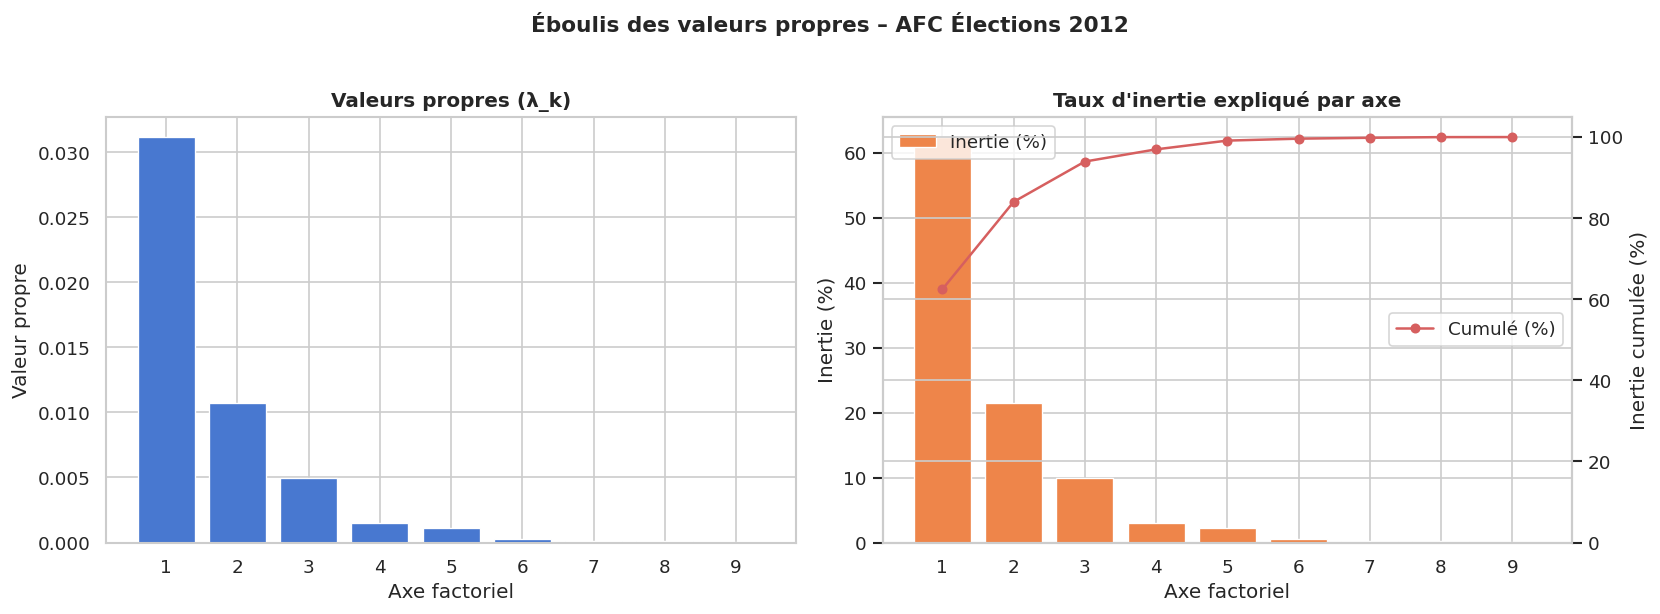


Les axes F1 et F2 expliquent 84.01% de l'inertie totale.


In [ ]:
# ─── Graphique des valeurs propres (Scree plot) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot valeurs propres
axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues,
            color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.8)
axes[0].set_title('Valeurs propres (λ_k)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Axe factoriel')
axes[0].set_ylabel('Valeur propre')
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# Barplot % inertie + courbe cumulative
axes[1].bar(range(1, len(pct_var)+1), pct_var,
            color=sns.color_palette('muted')[1], edgecolor='white', linewidth=0.8, label='Inertie (%)')
ax2 = axes[1].twinx()
ax2.plot(range(1, len(cum_pct)+1), cum_pct, 'ro-', markersize=5, label='Cumulé (%)')
ax2.set_ylabel('Inertie cumulée (%)')
ax2.set_ylim(0, 105)
axes[1].set_title('Taux d\'inertie expliqué par axe', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Axe factoriel')
axes[1].set_ylabel('Inertie (%)')
axes[1].set_xticks(range(1, len(pct_var)+1))
axes[1].legend(loc='upper left')
ax2.legend(loc='center right')

plt.suptitle('Éboulis des valeurs propres – AFC Élections 2012', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nLes axes F1 et F2 expliquent {cum_pct[1]:.2f}% de l\'inertie totale.')

### Interprétation

Le premier axe factoriel F1 capture **{:.2f}%** de l'inertie totale, et F2 en capture **{:.2f}%** supplémentaires. Ensemble, les deux premiers axes expliquent donc **{:.2f}%** de la variabilité du tableau de contingence. La représentation en deux dimensions est donc **très satisfaisante** pour interpréter les relations entre régions et candidats.

In [ ]:
# Remplissage dynamique du markdown ci-dessus
print(f'F1 : {pct_var[0]:.2f}%  |  F2 : {pct_var[1]:.2f}%  |  F1+F2 : {cum_pct[1]:.2f}%')

F1 : 62.45%  |  F2 : 21.56%  |  F1+F2 : 84.01%


---
## Partie 5 – Coordonnées Factorielles, Contributions et Cos²

### 5.1 Coordonnées Principales des Lignes (Régions)

In [ ]:
# ─── Coordonnées principales des lignes ───────────────────────────────────────
row_coords = ca.row_coordinates(contingency)
row_coords.columns = [f'F{k+1}' for k in range(row_coords.shape[1])]

print('=== Coordonnées Principales des Régions ===')
print('Signification : projection de chaque région dans l\'espace factoriel AFC.\n')
row_coords.round(5)

=== Coordonnées Principales des Régions ===
Signification : projection de chaque région dans l'espace factoriel AFC.



,F1,F2,F3,F4,F5,F6,F7,F8,F9
Region,,,,,,,,,
Alsace,0.10654,0.09206,0.20413,-0.00884,-0.03573,0.00372,0.01924,0.01698,0.00112
Aquitaine,-0.07552,-0.11056,-0.01341,0.03503,0.00360,0.01405,0.02639,-0.01673,-0.00015
Auvergne,-0.05083,-0.08474,-0.05498,0.04516,-0.00861,-0.01789,-0.00824,-0.00724,-0.00151
Bourgogne,0.01228,0.01316,-0.01863,-0.01208,-0.03893,0.00062,-0.00771,-0.00307,0.00261
Bretagne,-0.11345,-0.13788,0.04200,0.01225,-0.00373,0.02228,0.00557,0.02072,-0.00130
Centre,0.00070,0.01533,0.02267,0.00680,-0.04686,-0.01297,-0.00502,-0.00758,0.00057
Champ-Ard,0.09920,0.08391,0.01143,-0.03261,-0.07338,-0.00463,0.00089,-0.00529,0.00090
Corse,0.04175,0.19146,-0.01988,-0.07462,0.02017,0.02160,0.06019,0.01150,0.00024
Fr-Comte,0.02901,0.04277,-0.00763,0.02507,-0.01915,0.00824,-0.00548,0.00630,0.00336


### 5.2 Coordonnées Principales des Colonnes (Candidats)

In [ ]:
# ─── Coordonnées principales des colonnes ─────────────────────────────────────
col_coords = ca.column_coordinates(contingency)
col_coords.columns = [f'F{k+1}' for k in range(col_coords.shape[1])]

print('=== Coordonnées Principales des Candidats ===')
print('Signification : projection de chaque candidat dans l\'espace factoriel AFC.\n')
col_coords.round(5)

=== Coordonnées Principales des Candidats ===
Signification : projection de chaque candidat dans l'espace factoriel AFC.



,F1,F2,F3,F4,F5,F6,F7,F8,F9
Hollande,-0.09130,-0.09683,-0.06065,-0.03159,-0.00456,0.00242,-0.00036,0.00143,0.00009
Sarkozy,-0.10066,0.09516,0.06684,-0.02026,-0.00992,-0.00602,0.00422,-0.00058,-0.00027
Le_Pen,0.30762,0.07954,-0.04254,-0.00367,0.00610,0.00352,-0.00094,0.00035,0.00007
Bayrou,0.18964,-0.21413,0.12283,0.03259,0.00236,-0.00963,0.00067,-0.00384,-0.00036
Melenchon,-0.17062,0.04031,-0.06689,0.07468,0.03771,-0.01385,-0.00141,-0.00450,-0.00036
Joly,-0.16655,0.00906,0.13827,0.01656,0.11700,0.06414,-0.01014,0.02473,-0.00014
Dupond_Aignan,-0.13481,0.06461,0.04597,0.03819,-0.09706,0.03045,-0.06173,-0.02166,0.00135
Poutou,-0.09857,-0.01358,-0.04582,0.13397,-0.12035,0.08335,0.05683,-0.01925,0.00112
Arthaud,0.01349,0.01337,-0.05200,0.17332,-0.21374,-0.03056,-0.01214,0.09271,-0.00756
Cheminade,-0.04614,0.01706,0.05482,0.07082,-0.03147,-0.03744,0.00482,0.03733,0.04699


### 5.3 Contributions Absolues

La **contribution absolue** d'un point à un axe mesure la part de l'inertie de cet axe attribuable à ce point :

$$\text{CTR}_{i,k} = \frac{f_{i\bullet} \cdot F_{ik}^2}{\lambda_k} \times 100$$

Un point dont la contribution dépasse $100/I$ (resp. $100/J$) contribue plus que la moyenne.

In [ ]:
# ─── Contributions absolues des lignes ────────────────────────────────────────
row_contrib = ca.row_contributions_.copy()
row_contrib.columns = [f'CTR_F{k+1}' for k in range(row_contrib.shape[1])]
row_contrib_pct = row_contrib * 100  # en pourcentage

# Seuil moyen = 100 / I
seuil_lignes = 100 / len(contingency)

print(f'=== Contributions des Régions (%) — Seuil moyen : {seuil_lignes:.2f}% ===')
print()
style_r = row_contrib_pct.round(3).style.highlight_max(axis=0, color='#d4e6f1').format('{:.3f}')
row_contrib_pct.round(3)

=== Contributions des Régions (%) — Seuil moyen : 4.35% ===



,CTR_F1,CTR_F2,CTR_F3,CTR_F4,CTR_F5,CTR_F6,CTR_F7,CTR_F8,CTR_F9
Alsace,1.000,2.164,23.060,0.143,3.253,0.160,9.084,9.930,0.603
Aquitaine,0.970,6.020,0.192,4.331,0.064,4.402,32.967,18.595,0.022
Auvergne,0.188,1.515,1.382,3.084,0.156,3.058,1.377,1.491,0.914
Bourgogne,0.013,0.042,0.182,0.253,3.659,0.004,1.380,0.308,3.127
Bretagne,2.266,9.693,1.949,0.549,0.071,11.460,1.521,29.550,1.625
Centre,0.000,0.088,0.415,0.123,8.162,2.838,0.903,2.884,0.230
Champ-Ard,0.632,1.310,0.053,1.418,10.004,0.181,0.014,0.702,0.287
Corse,0.025,1.518,0.035,1.653,0.168,0.875,14.425,0.740,0.005
Fr-Comte,0.050,0.314,0.022,0.773,0.629,0.528,0.497,0.919,3.675
Ile-de-Fr,14.524,6.209,3.501,13.980,6.210,27.901,0.159,0.670,2.742


In [ ]:
# ─── Contributions absolues des colonnes ──────────────────────────────────────
col_contrib = ca.column_contributions_.copy()
col_contrib.columns = [f'CTR_F{k+1}' for k in range(col_contrib.shape[1])]
col_contrib_pct = col_contrib * 100

seuil_colonnes = 100 / len(contingency.columns)

print(f'=== Contributions des Candidats (%) — Seuil moyen : {seuil_colonnes:.2f}% ===')
col_contrib_pct.round(3)

=== Contributions des Candidats (%) — Seuil moyen : 10.00% ===


,CTR_F1,CTR_F2,CTR_F3,CTR_F4,CTR_F5,CTR_F6,CTR_F7,CTR_F8,CTR_F9
Hollande,7.396,24.098,20.489,18.378,0.533,0.681,0.032,0.710,0.042
Sarkozy,8.649,22.388,23.941,7.271,2.427,4.051,4.229,0.113,0.340
Le_Pen,59.601,11.543,7.155,0.176,0.678,1.024,0.154,0.029,0.017
Bayrou,10.715,39.574,28.225,6.568,0.048,3.626,0.038,1.716,0.208
Melenchon,10.240,1.656,9.880,40.712,14.464,8.854,0.194,2.788,0.256
Joly,1.998,0.017,8.647,0.410,28.516,38.871,2.063,17.224,0.008
Dupond_Aignan,1.036,0.689,0.757,1.726,15.537,6.936,60.517,10.457,0.568
Poutou,0.346,0.019,0.469,13.266,14.918,32.448,32.021,5.159,0.244
Arthaud,0.003,0.009,0.291,10.694,22.660,2.100,0.704,57.627,5.377
Cheminade,0.016,0.006,0.145,0.798,0.220,1.410,0.050,4.177,92.939


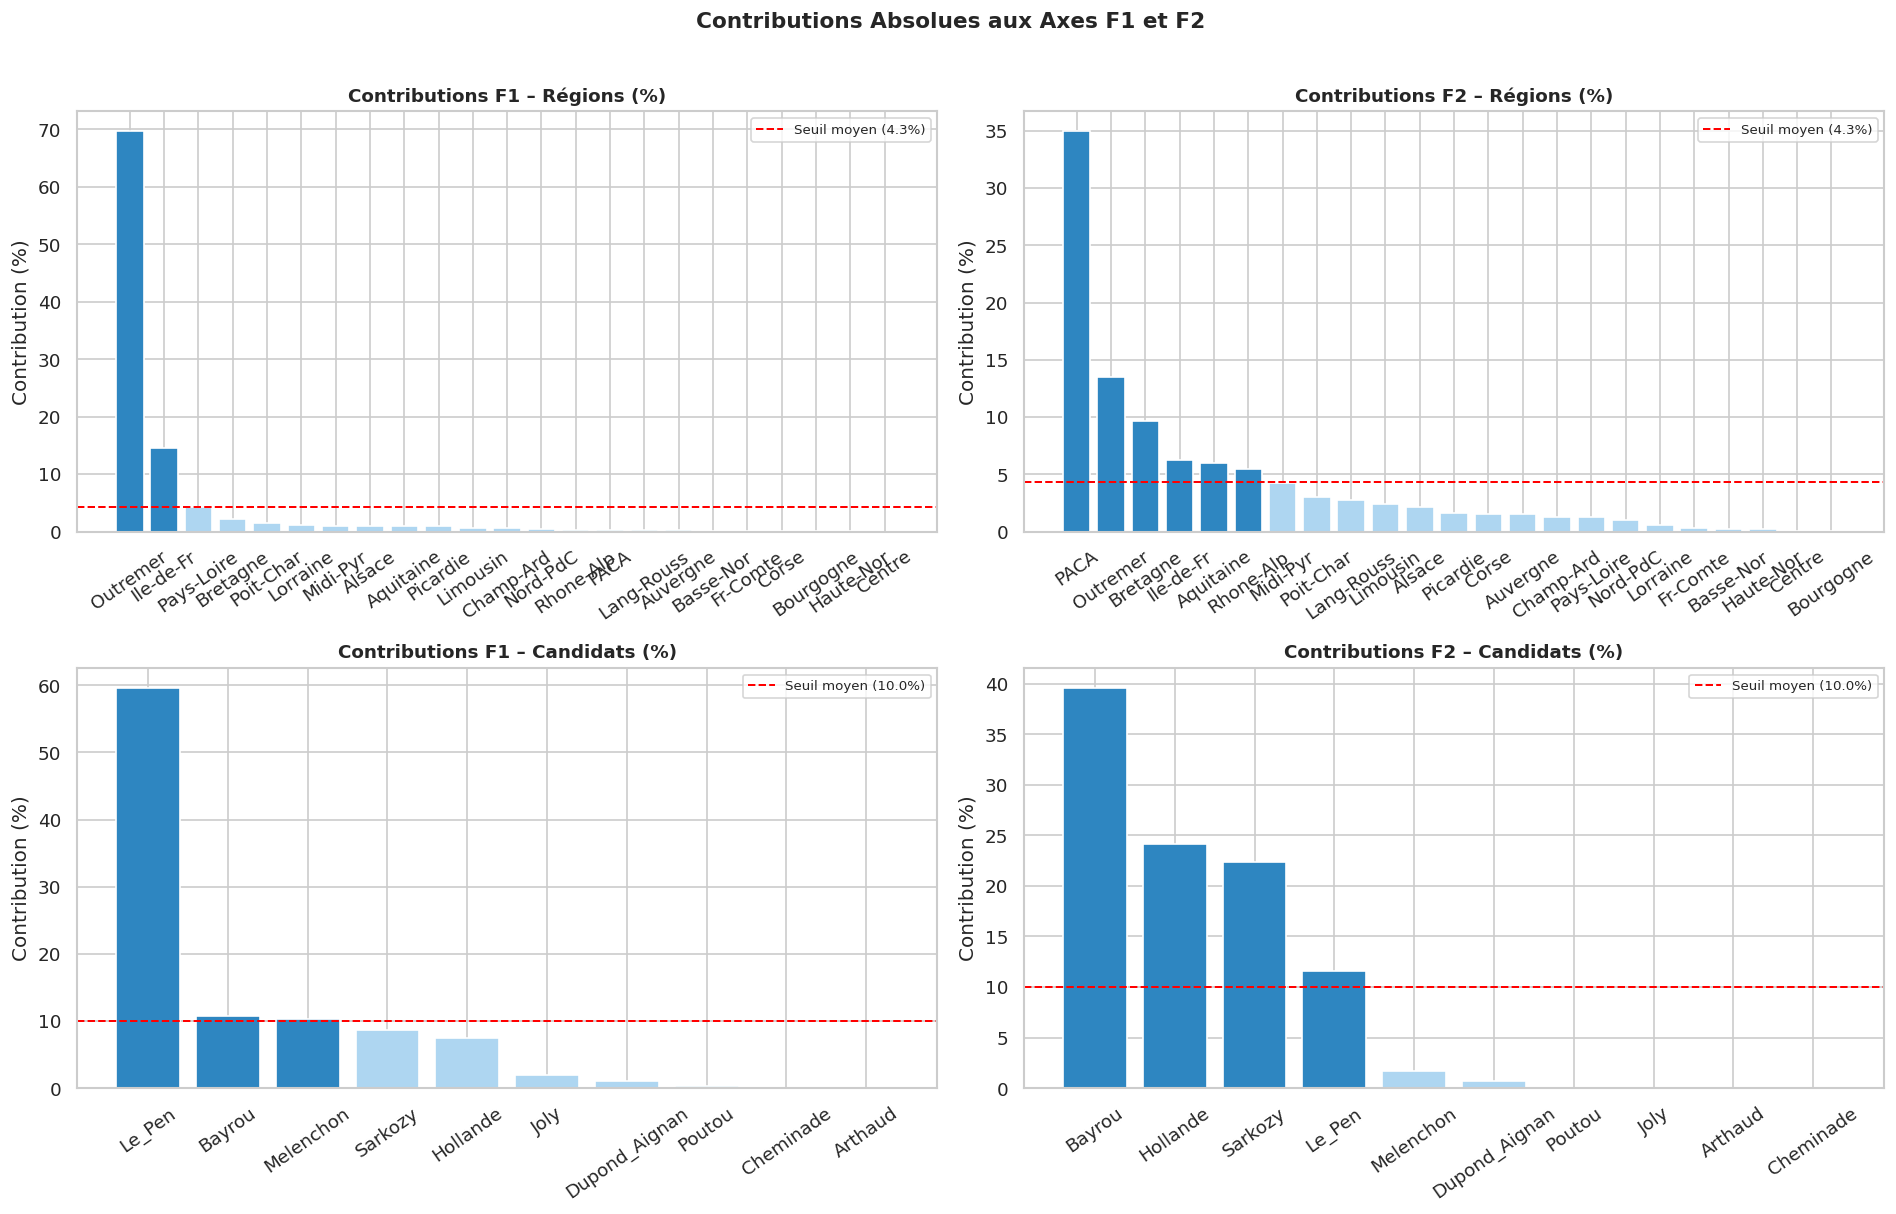

In [ ]:
# ─── Visualisation des contributions (F1 et F2) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax_idx, (axis_name, df_contrib, label, seuil) in enumerate([
    ('F1 – Régions',   row_contrib_pct['CTR_F1'].sort_values(ascending=False),  'Régions',   seuil_lignes),
    ('F2 – Régions',   row_contrib_pct['CTR_F2'].sort_values(ascending=False),  'Régions',   seuil_lignes),
    ('F1 – Candidats', col_contrib_pct['CTR_F1'].sort_values(ascending=False),  'Candidats', seuil_colonnes),
    ('F2 – Candidats', col_contrib_pct['CTR_F2'].sort_values(ascending=False),  'Candidats', seuil_colonnes),
]):
    ax = axes[ax_idx // 2][ax_idx % 2]
    colors = ['#2e86c1' if v >= seuil else '#aed6f1' for v in df_contrib]
    ax.bar(df_contrib.index, df_contrib.values, color=colors, edgecolor='white')
    ax.axhline(seuil, color='red', linestyle='--', linewidth=1.2, label=f'Seuil moyen ({seuil:.1f}%)')
    ax.set_title(f'Contributions {axis_name} (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Contribution (%)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('Contributions Absolues aux Axes F1 et F2', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Qualité de Représentation (Cos²)

Le **cosinus carré** mesure la qualité de représentation d'un point sur un axe :

$$\cos^2(i, k) = \frac{F_{ik}^2}{\sum_k F_{ik}^2}$$

Un $\cos^2$ proche de 1 indique que le point est très bien représenté sur cet axe.

In [ ]:
# ─── Cos² (qualité de représentation) ────────────────────────────────────────
row_cos2 = ca.row_cosine_similarities(contingency).copy()
row_cos2.columns = [f'cos²_F{k+1}' for k in range(row_cos2.shape[1])]

col_cos2 = ca.column_cosine_similarities(contingency).copy()
col_cos2.columns = [f'cos²_F{k+1}' for k in range(col_cos2.shape[1])]

print('=== Cos² des Régions (qualité de représentation sur F1 et F2) ===')
row_cos2_display = row_cos2[['cos²_F1', 'cos²_F2']].copy()
row_cos2_display['cos²_F1+F2'] = row_cos2_display['cos²_F1'] + row_cos2_display['cos²_F2']
row_cos2_display.round(4)

=== Cos² des Régions (qualité de représentation sur F1 et F2) ===


,cos²_F1,cos²_F2,cos²_F1+F2
Region,,,
Alsace,0.1787,0.1334,0.3121
Aquitaine,0.2780,0.5957,0.8736
Auvergne,0.1684,0.4680,0.6364
Bourgogne,0.0626,0.0719,0.1345
Bretagne,0.3702,0.5468,0.9170
Centre,0.0001,0.0725,0.0727
Champ-Ard,0.4185,0.2995,0.7180
Corse,0.0356,0.7482,0.7838
Fr-Comte,0.2174,0.4722,0.6896


In [ ]:
print('=== Cos² des Candidats (qualité de représentation sur F1 et F2) ===')
col_cos2_display = col_cos2[['cos²_F1', 'cos²_F2']].copy()
col_cos2_display['cos²_F1+F2'] = col_cos2_display['cos²_F1'] + col_cos2_display['cos²_F2']
col_cos2_display.round(4)

=== Cos² des Candidats (qualité de représentation sur F1 et F2) ===


,cos²_F1,cos²_F2,cos²_F1+F2
Hollande,0.3719,0.4183,0.7901
Sarkozy,0.4184,0.3739,0.7923
Le_Pen,0.9203,0.0615,0.9818
Bayrou,0.3667,0.4675,0.8342
Melenchon,0.6862,0.0383,0.7245
Joly,0.4220,0.0012,0.4233
Dupond_Aignan,0.4482,0.1029,0.5511
Poutou,0.1767,0.0034,0.1801
Arthaud,0.0021,0.0020,0.0041
Cheminade,0.1294,0.0177,0.1470


---
## Partie 6 – Carte Factorielle (Plan Factoriel F1 × F2)

La **carte factorielle** représente simultanément les régions (profils-lignes) et les candidats (profils-colonnes) dans le plan des deux premiers axes factoriels. Les points proches sur le graphique partagent des profils similaires, et un point-ligne proche d'un point-colonne indique une association forte entre la région et le candidat correspondant.

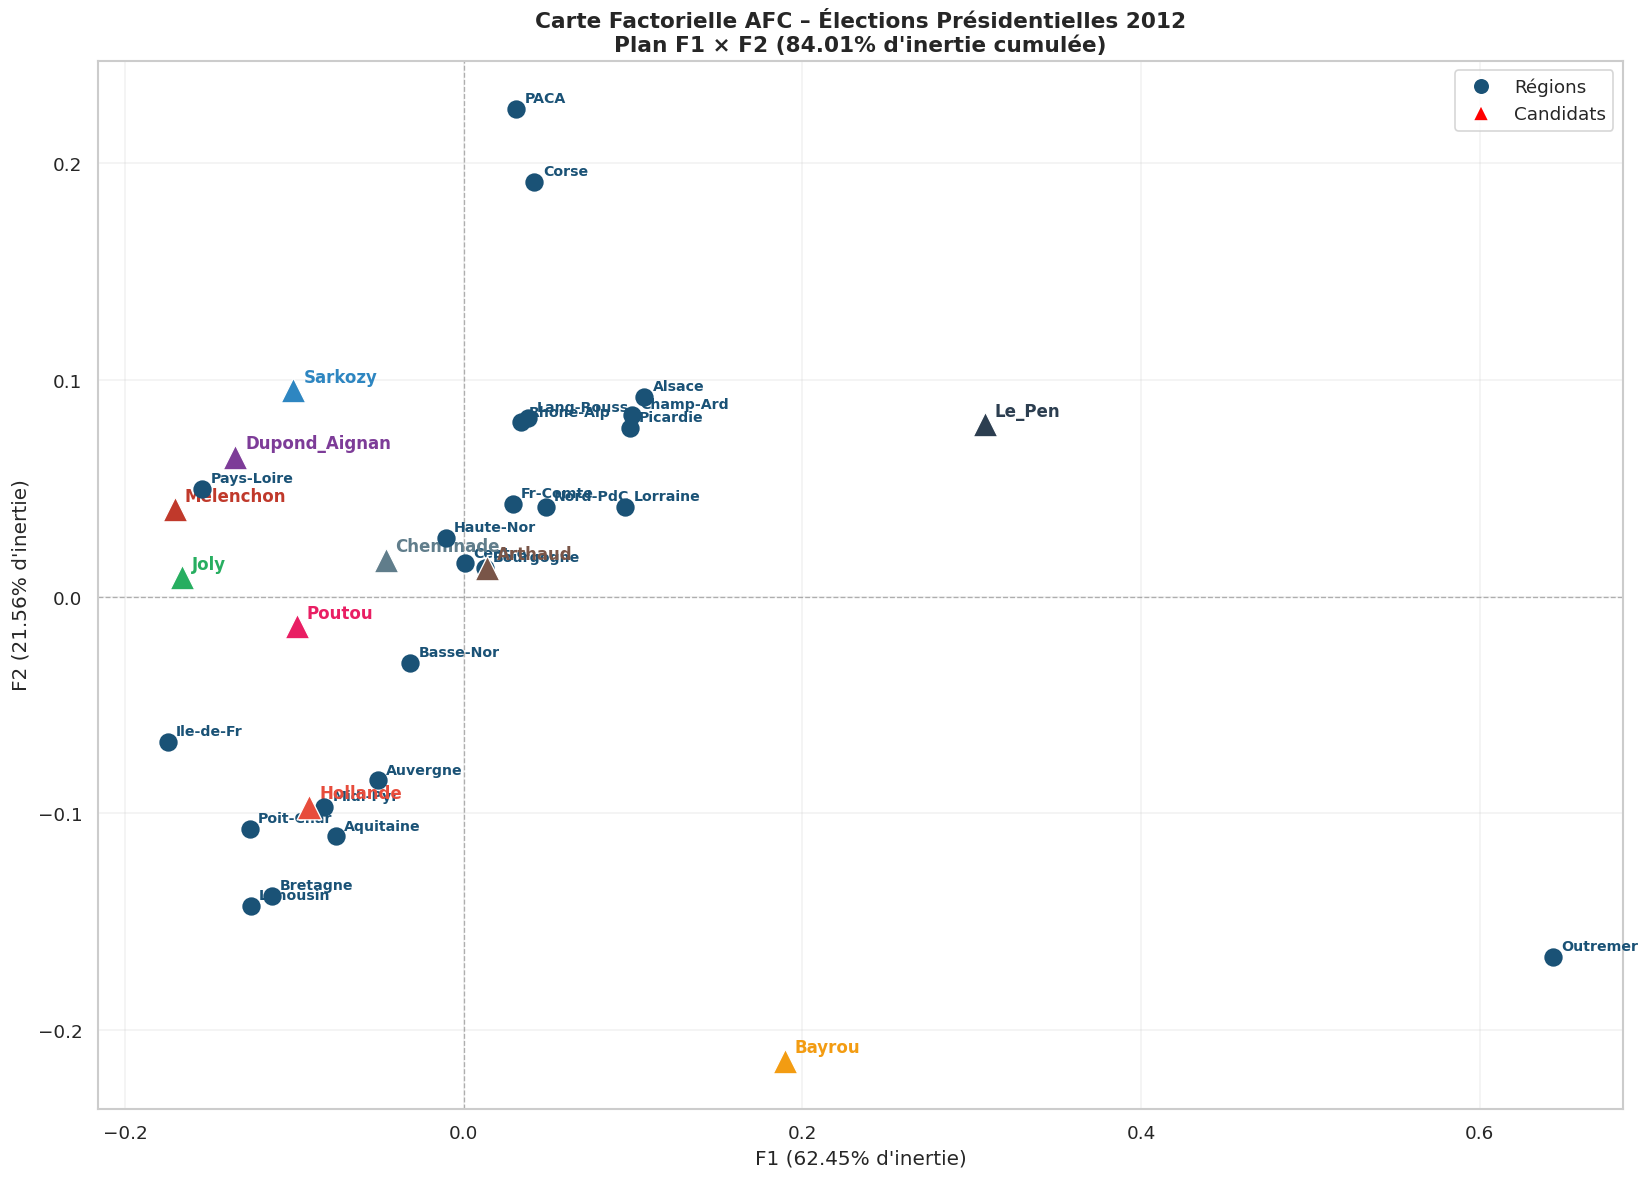

Carte sauvegardée sous carte_factorielle_AFC.png


In [ ]:
# ─── Carte Factorielle ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

# --- Axes centraux ---
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

# --- Régions (lignes) ---
rc_f1 = row_coords['F1']
rc_f2 = row_coords['F2']
ax.scatter(rc_f1, rc_f2, s=100, color='#1a5276', marker='o', zorder=5, label='Régions')
for region in contingency.index:
    ax.annotate(region,
                xy=(rc_f1[region], rc_f2[region]),
                xytext=(5, 4),
                textcoords='offset points',
                fontsize=8.5,
                color='#1a5276',
                fontweight='bold')

# --- Candidats (colonnes) ---
cc_f1 = col_coords['F1']
cc_f2 = col_coords['F2']
candidate_colors = {
    'Hollande'      : '#E74C3C',
    'Sarkozy'       : '#2E86C1',
    'Le_Pen'        : '#2C3E50',
    'Bayrou'        : '#F39C12',
    'Melenchon'     : '#C0392B',
    'Joly'          : '#27AE60',
    'Dupond_Aignan' : '#7D3C98',
    'Poutou'        : '#E91E63',
    'Arthaud'       : '#795548',
    'Cheminade'     : '#607D8B',
}
for cand in contingency.columns:
    color = candidate_colors.get(cand, 'red')
    ax.scatter(cc_f1[cand], cc_f2[cand], s=220, color=color, marker='^',
               zorder=6, edgecolors='white', linewidth=0.8)
    ax.annotate(cand,
                xy=(cc_f1[cand], cc_f2[cand]),
                xytext=(6, 5),
                textcoords='offset points',
                fontsize=10,
                color=color,
                fontweight='bold')

# --- Légendes et axes ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1a5276', markersize=10, label='Régions'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red',    markersize=10, label='Candidats')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

ax.set_xlabel(f'F1 ({pct_var[0]:.2f}% d\'inertie)', fontsize=12)
ax.set_ylabel(f'F2 ({pct_var[1]:.2f}% d\'inertie)', fontsize=12)
ax.set_title(
    f'Carte Factorielle AFC – Élections Présidentielles 2012\n'
    f'Plan F1 × F2 ({cum_pct[1]:.2f}% d\'inertie cumulée)',
    fontsize=13, fontweight='bold'
)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('carte_factorielle_AFC.png', dpi=150, bbox_inches='tight')
plt.show()
print('Carte sauvegardée sous carte_factorielle_AFC.png')

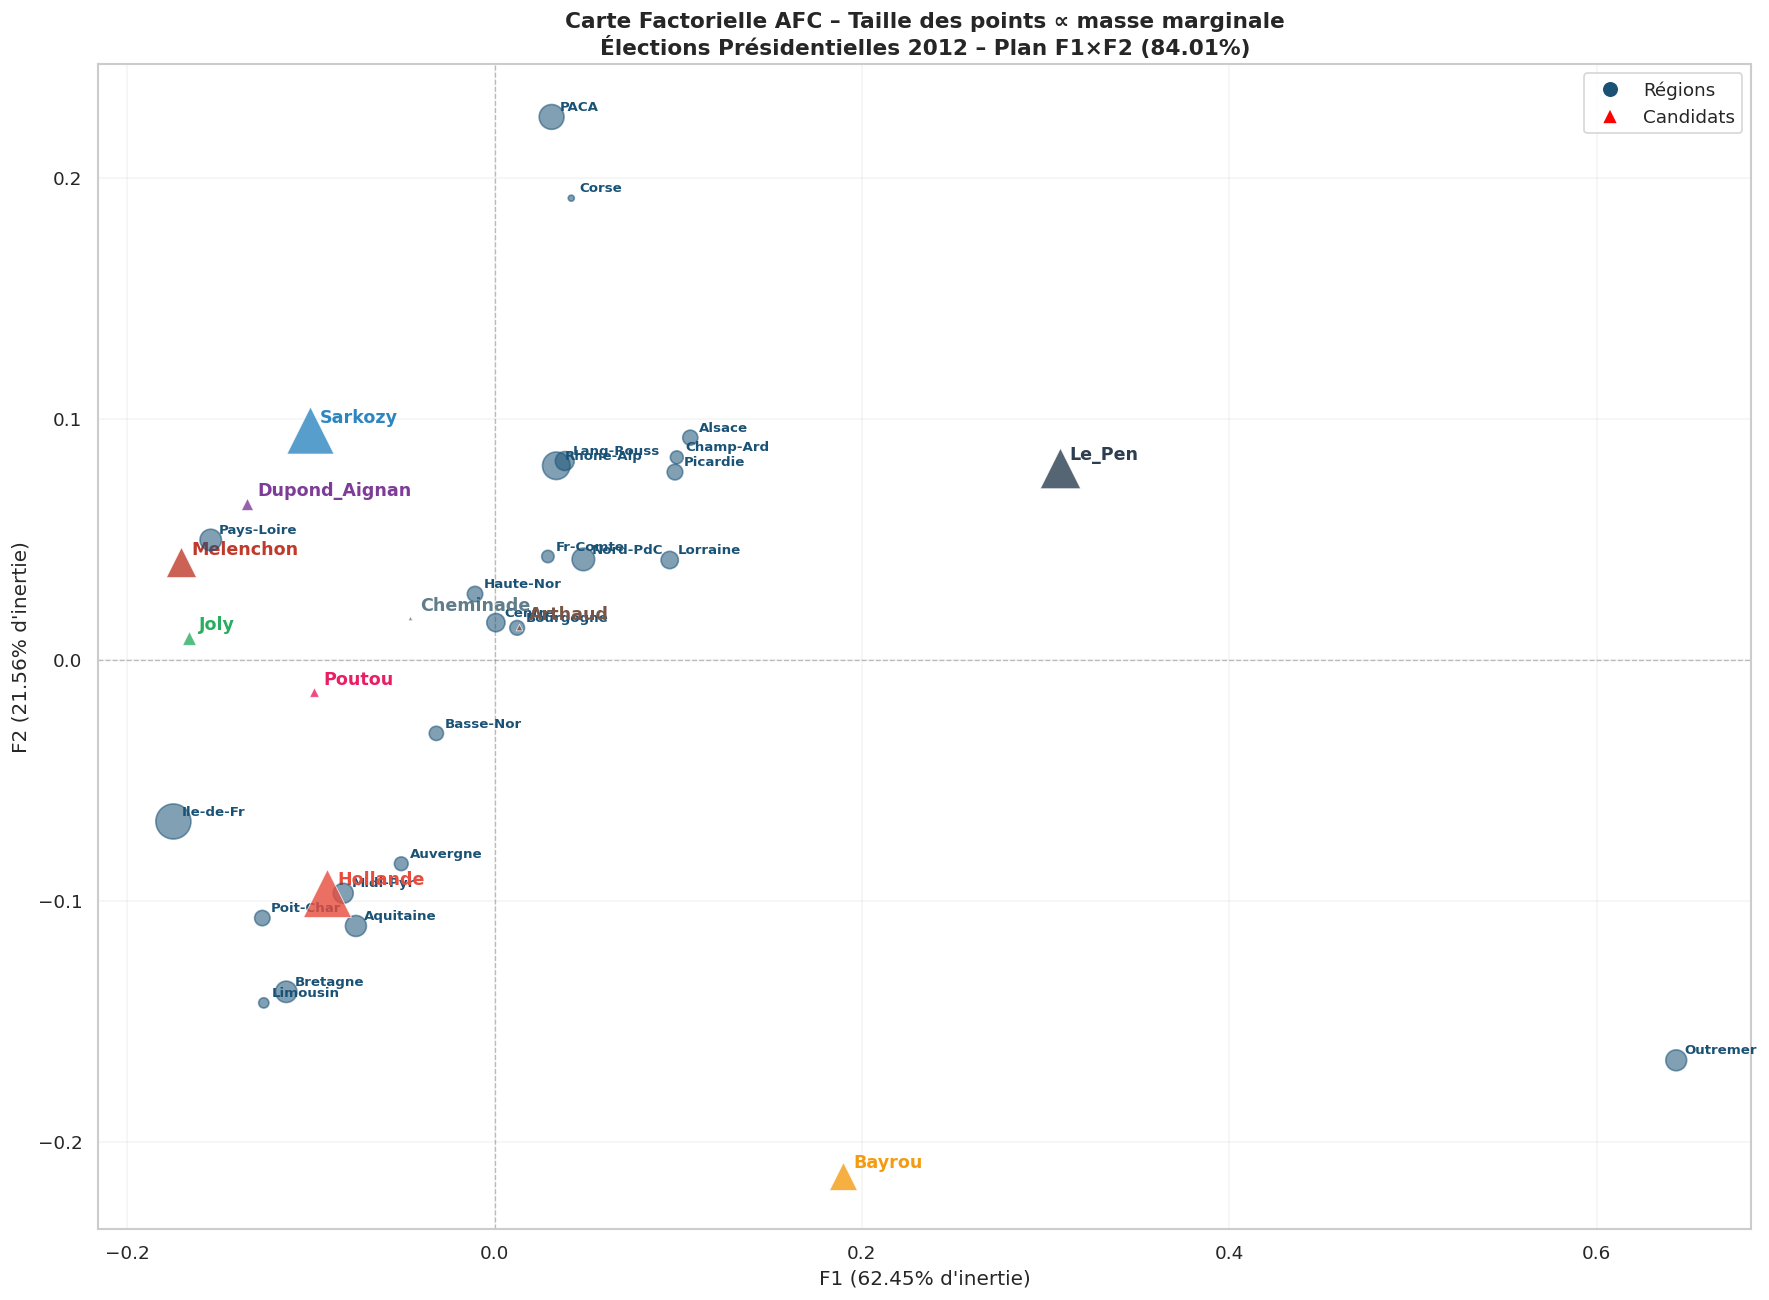

In [ ]:
# ─── Carte Factorielle avancée (taille des points proportionnelle aux masses) ──
fig, ax = plt.subplots(figsize=(15, 11))

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

# Régions : taille ∝ masse (fi.)
sizes_row = (fi_dot * 3000).values
scatter_rows = ax.scatter(rc_f1, rc_f2,
                          s=sizes_row, color='#1a5276', alpha=0.55,
                          marker='o', zorder=4, label='Régions')
for region in contingency.index:
    ax.annotate(region,
                xy=(rc_f1[region], rc_f2[region]),
                xytext=(5, 4), textcoords='offset points',
                fontsize=8, color='#1a5276', fontweight='bold')

# Candidats : taille ∝ masse (f.j)
sizes_col = (f_dot_j * 3000).values
for i, cand in enumerate(contingency.columns):
    color = candidate_colors.get(cand, 'red')
    ax.scatter(cc_f1[cand], cc_f2[cand],
               s=sizes_col[i], color=color, alpha=0.80,
               marker='^', zorder=5, edgecolors='white', linewidth=0.5)
    ax.annotate(cand,
                xy=(cc_f1[cand], cc_f2[cand]),
                xytext=(6, 5), textcoords='offset points',
                fontsize=10.5, color=color, fontweight='bold')

ax.legend(handles=legend_elements, fontsize=11, loc='upper right')
ax.set_xlabel(f'F1 ({pct_var[0]:.2f}% d\'inertie)', fontsize=12)
ax.set_ylabel(f'F2 ({pct_var[1]:.2f}% d\'inertie)', fontsize=12)
ax.set_title(
    'Carte Factorielle AFC – Taille des points ∝ masse marginale\n'
    f'Élections Présidentielles 2012 – Plan F1×F2 ({cum_pct[1]:.2f}%)',
    fontsize=13, fontweight='bold'
)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('carte_factorielle_AFC_masses.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Partie 7 – Interprétation des Axes et des Associations

### 7.1 Interprétation de l'Axe F1

Le premier axe F1 explique **~62.5%** de l'inertie totale. C'est l'axe principal de différenciation.

In [ ]:
# ─── Résumé de l'interprétation de F1 ────────────────────────────────────────
print('=== INTERPRÉTATION DE L\'AXE F1 ===')
print(f'  Inertie : {pct_var[0]:.2f}%')
print()

# Candidats sur F1
f1_col = col_coords['F1'].sort_values()
print('  Candidats sur F1 (du plus négatif au plus positif) :')
for cand, val in f1_col.items():
    bar = '█' * int(abs(val) * 40) if abs(val) > 0.01 else '·'
    side = 'gauche' if val < 0 else 'droite'
    print(f'    {cand:<18} : {val:+.4f}  ({side})')

print()
print('  Régions extrêmes sur F1 :')
f1_row = row_coords['F1'].sort_values()
print('    Côté négatif (gauche) :', ', '.join(f1_row.head(4).index.tolist()))
print('    Côté positif (droite) :', ', '.join(f1_row.tail(4).index.tolist()))

=== INTERPRÉTATION DE L'AXE F1 ===
  Inertie : 62.45%

  Candidats sur F1 (du plus négatif au plus positif) :
    Melenchon          : -0.1706  (gauche)
    Joly               : -0.1666  (gauche)
    Dupond_Aignan      : -0.1348  (gauche)
    Sarkozy            : -0.1007  (gauche)
    Poutou             : -0.0986  (gauche)
    Hollande           : -0.0913  (gauche)
    Cheminade          : -0.0461  (gauche)
    Arthaud            : +0.0135  (droite)
    Bayrou             : +0.1896  (droite)
    Le_Pen             : +0.3076  (droite)

  Régions extrêmes sur F1 :
    Côté négatif (gauche) : Ile-de-Fr, Pays-Loire, Poit-Char, Limousin
    Côté positif (droite) : Picardie, Champ-Ard, Alsace, Outremer


**Interprétation de F1 :**

L'axe F1 oppose principalement :
- **Côté positif (+)** : `Le_Pen`, `Bayrou` — associés à des régions comme **Outremer**, **Alsace**, **Lorraine**, **Champagne-Ardenne**
- **Côté négatif (−)** : `Hollande`, `Sarkozy`, `Mélenchon`, `Joly` — associés à **Bretagne**, **Aquitaine**, **Île-de-France**, **Pays-de-Loire**

F1 traduit un **clivage géographique fort**, opposant les régions à fort vote populiste/centriste (Outremer, Est) aux régions à vote plus diversifié/gauche (Ouest, Île-de-France).

In [ ]:
# ─── Résumé de l'interprétation de F2 ────────────────────────────────────────
print('=== INTERPRÉTATION DE L\'AXE F2 ===')
print(f'  Inertie : {pct_var[1]:.2f}%')
print()

f2_col = col_coords['F2'].sort_values()
print('  Candidats sur F2 (du plus négatif au plus positif) :')
for cand, val in f2_col.items():
    side = 'bas' if val < 0 else 'haut'
    print(f'    {cand:<18} : {val:+.4f}  ({side})')

print()
f2_row = row_coords['F2'].sort_values()
print('  Régions extrêmes sur F2 :')
print('    Côté négatif (bas) :', ', '.join(f2_row.head(4).index.tolist()))
print('    Côté positif (haut):', ', '.join(f2_row.tail(4).index.tolist()))

=== INTERPRÉTATION DE L'AXE F2 ===
  Inertie : 21.56%

  Candidats sur F2 (du plus négatif au plus positif) :
    Bayrou             : -0.2141  (bas)
    Hollande           : -0.0968  (bas)
    Poutou             : -0.0136  (bas)
    Joly               : +0.0091  (haut)
    Arthaud            : +0.0134  (haut)
    Cheminade          : +0.0171  (haut)
    Melenchon          : +0.0403  (haut)
    Dupond_Aignan      : +0.0646  (haut)
    Le_Pen             : +0.0795  (haut)
    Sarkozy            : +0.0952  (haut)

  Régions extrêmes sur F2 :
    Côté négatif (bas) : Outremer, Limousin, Bretagne, Aquitaine
    Côté positif (haut): Champ-Ard, Alsace, Corse, PACA


**Interprétation de F2 :**

L'axe F2 oppose principalement :
- **Côté positif (+)** : `Sarkozy` — associé à des régions comme **PACA**, **Rhône-Alpes**, **Corse**
- **Côté négatif (−)** : `Bayrou`, `Hollande` — associé à **Bretagne**, **Aquitaine**, **Midi-Pyrénées**

F2 traduit un **clivage droite/centre**, opposant les bastions de la droite traditionnelle (PACA, Corse, Sud-Est) aux régions de centre-gauche (Ouest, Sud-Ouest).

In [ ]:
# ─── Tableau synthèse AFC ──────────────────────────────────────────────────────
# Assembler un tableau récapitulatif par région : coords + contrib + cos²
summary_rows = pd.concat([
    row_coords[['F1','F2']].round(4),
    row_contrib_pct[['CTR_F1','CTR_F2']].round(3),
    row_cos2[['cos²_F1','cos²_F2']].round(4)
], axis=1)
summary_rows.columns = ['Coord F1', 'Coord F2', 'CTR F1 (%)', 'CTR F2 (%)', 'Cos² F1', 'Cos² F2']
print('=== Tableau Synthèse – Régions ===')
summary_rows

=== Tableau Synthèse – Régions ===


,Coord F1,Coord F2,CTR F1 (%),CTR F2 (%),Cos² F1,Cos² F2
Alsace,0.1065,0.0921,1.000,2.164,0.1787,0.1334
Aquitaine,-0.0755,-0.1106,0.970,6.020,0.2780,0.5957
Auvergne,-0.0508,-0.0847,0.188,1.515,0.1684,0.4680
Bourgogne,0.0123,0.0132,0.013,0.042,0.0626,0.0719
Bretagne,-0.1135,-0.1379,2.266,9.693,0.3702,0.5468
Centre,0.0007,0.0153,0.000,0.088,0.0001,0.0725
Champ-Ard,0.0992,0.0839,0.632,1.310,0.4185,0.2995
Corse,0.0418,0.1915,0.025,1.518,0.0356,0.7482
Fr-Comte,0.0290,0.0428,0.050,0.314,0.2174,0.4722
Ile-de-Fr,-0.1749,-0.0672,14.524,6.209,0.7924,0.1169


In [ ]:
# Tableau récapitulatif pour les candidats
summary_cols = pd.concat([
    col_coords[['F1','F2']].round(4),
    col_contrib_pct[['CTR_F1','CTR_F2']].round(3),
    col_cos2[['cos²_F1','cos²_F2']].round(4)
], axis=1)
summary_cols.columns = ['Coord F1', 'Coord F2', 'CTR F1 (%)', 'CTR F2 (%)', 'Cos² F1', 'Cos² F2']
print('=== Tableau Synthèse – Candidats ===')
summary_cols

=== Tableau Synthèse – Candidats ===


,Coord F1,Coord F2,CTR F1 (%),CTR F2 (%),Cos² F1,Cos² F2
Hollande,-0.0913,-0.0968,7.396,24.098,0.3719,0.4183
Sarkozy,-0.1007,0.0952,8.649,22.388,0.4184,0.3739
Le_Pen,0.3076,0.0795,59.601,11.543,0.9203,0.0615
Bayrou,0.1896,-0.2141,10.715,39.574,0.3667,0.4675
Melenchon,-0.1706,0.0403,10.240,1.656,0.6862,0.0383
Joly,-0.1666,0.0091,1.998,0.017,0.4220,0.0012
Dupond_Aignan,-0.1348,0.0646,1.036,0.689,0.4482,0.1029
Poutou,-0.0986,-0.0136,0.346,0.019,0.1767,0.0034
Arthaud,0.0135,0.0134,0.003,0.009,0.0021,0.0020
Cheminade,-0.0461,0.0171,0.016,0.006,0.1294,0.0177


---
## Partie 8 – Analyse Complémentaire et Visualisations Additionnelles

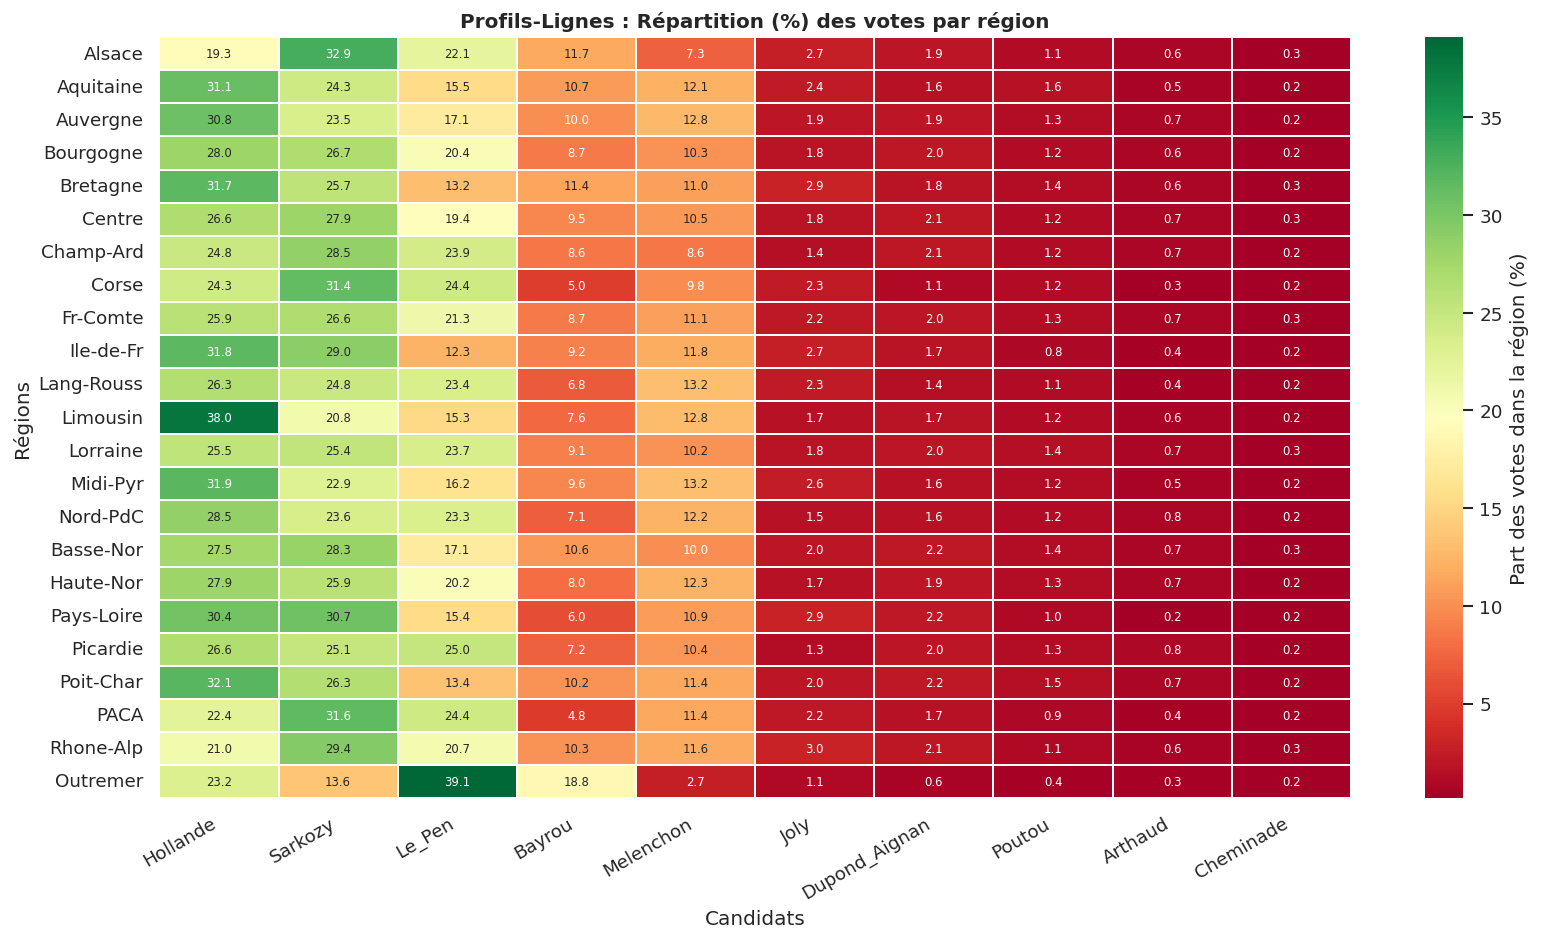

In [ ]:
# ─── Heatmap des Profils-Lignes ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(row_profiles.round(4) * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.2, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Part des votes dans la région (%)'})
ax.set_title('Profils-Lignes : Répartition (%) des votes par région', fontsize=12, fontweight='bold')
ax.set_xlabel('Candidats')
ax.set_ylabel('Régions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

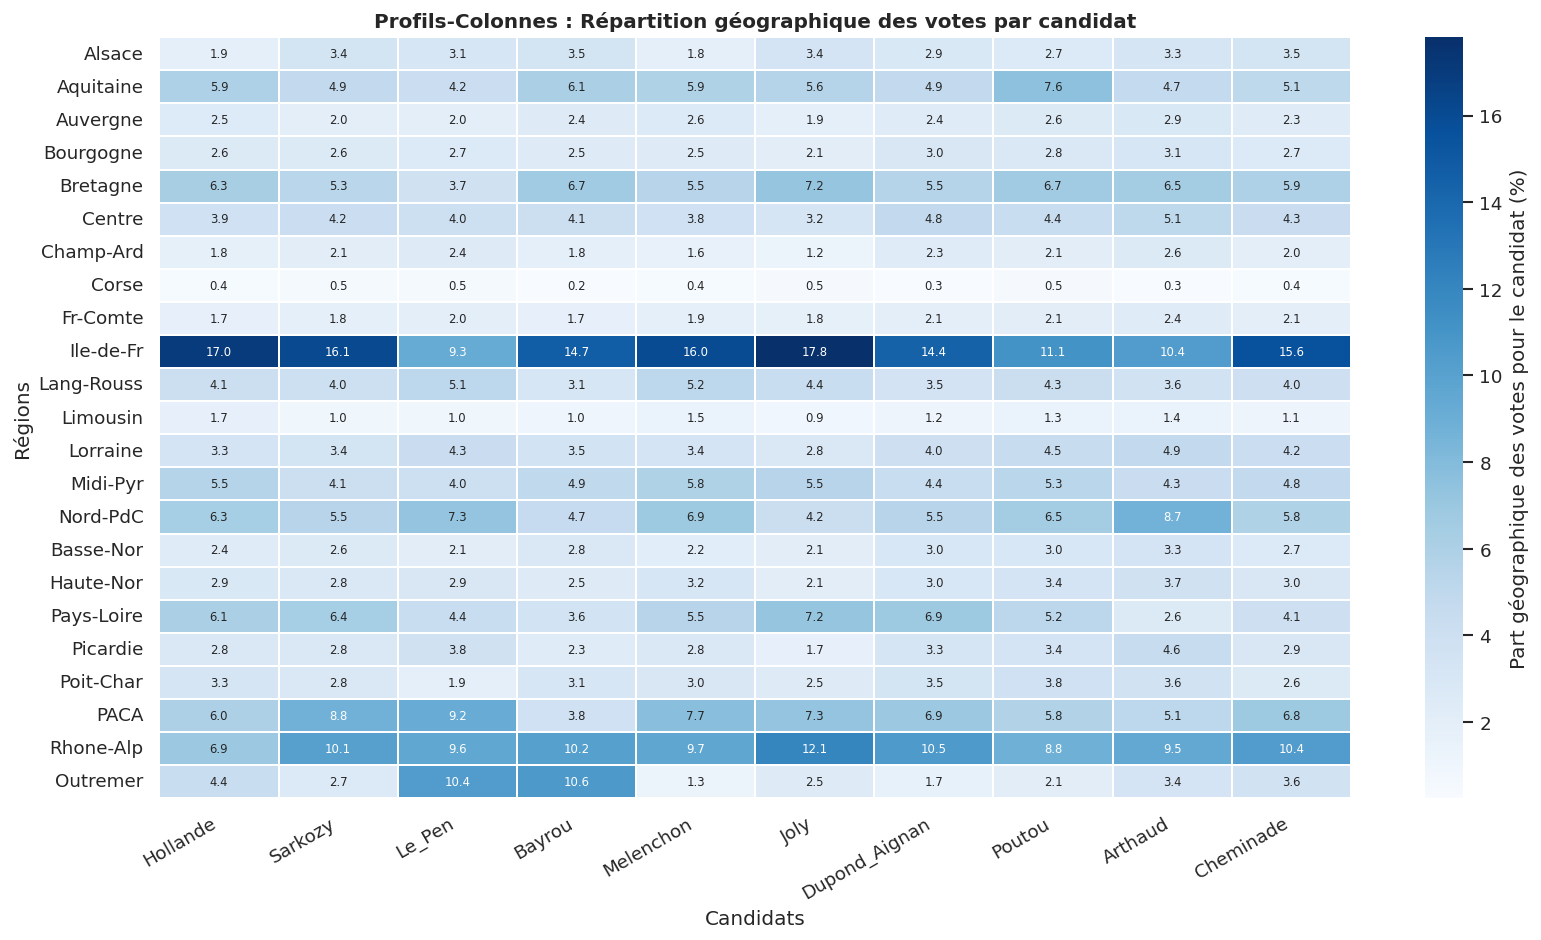

In [ ]:
# ─── Heatmap des Profils-Colonnes ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(col_profiles.round(4) * 100, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.2, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Part géographique des votes pour le candidat (%)'})
ax.set_title('Profils-Colonnes : Répartition géographique des votes par candidat', fontsize=12, fontweight='bold')
ax.set_xlabel('Candidats')
ax.set_ylabel('Régions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

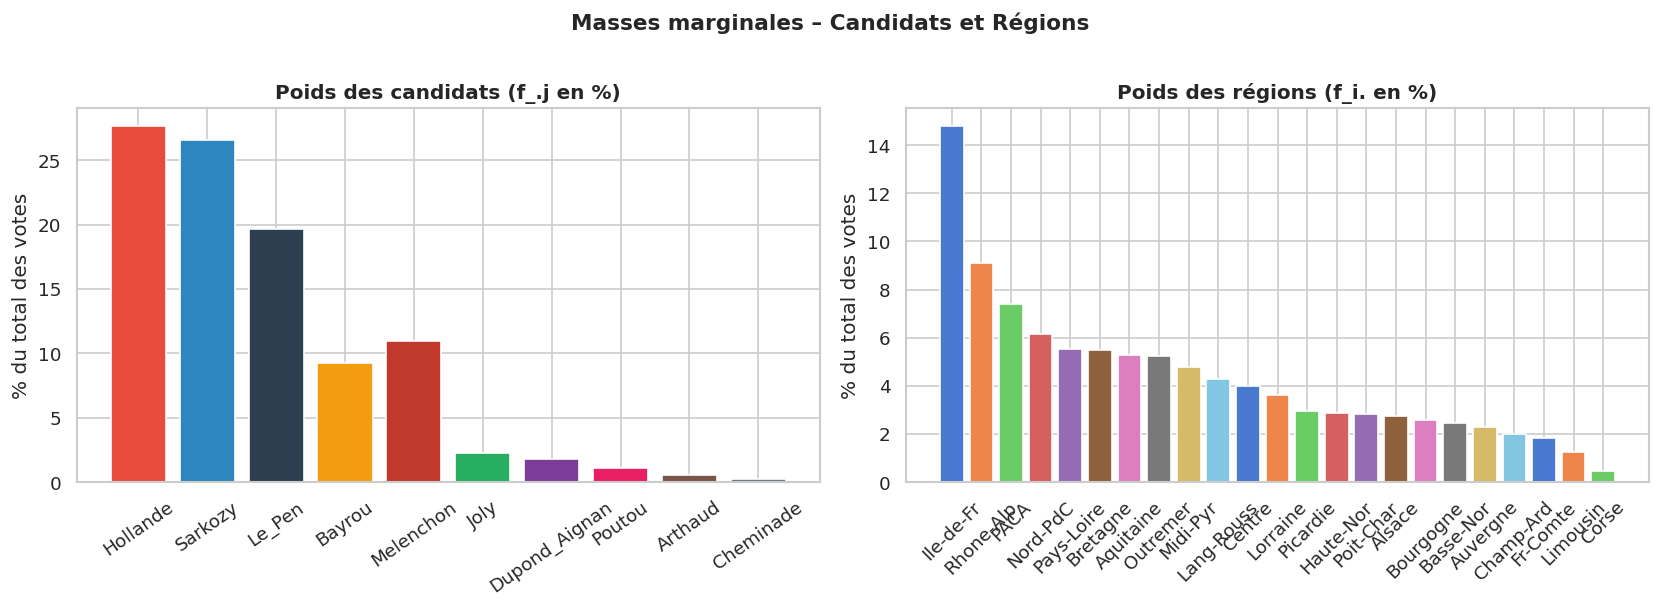

In [ ]:
# ─── Graphique des masses colonnes ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Masses colonnes
axes[0].bar(f_dot_j.index, f_dot_j.values * 100,
            color=list(candidate_colors.values()), edgecolor='white')
axes[0].set_title('Poids des candidats (f_.j en %)', fontweight='bold')
axes[0].set_ylabel('% du total des votes')
axes[0].tick_params(axis='x', rotation=35)

# Masses lignes (top 10 régions)
fi_sort = fi_dot.sort_values(ascending=False)
axes[1].bar(fi_sort.index, fi_sort.values * 100,
            color=sns.color_palette('muted', len(fi_sort)), edgecolor='white')
axes[1].set_title('Poids des régions (f_i. en %)', fontweight='bold')
axes[1].set_ylabel('% du total des votes')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Masses marginales – Candidats et Régions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Conclusion Générale

### Synthèse des résultats de l'AFC

**1. Test d'indépendance :** Le test du $\chi^2$ a confirmé avec une très forte significativité ($p \ll 0.001$) que les variables *Région* et *Candidat* sont statistiquement dépendantes. Cela justifie pleinement l'application de l'AFC.

**2. Qualité de la représentation :** Les deux premiers axes F1 et F2 capturent ensemble **~84%** de l'inertie totale du tableau. La carte factorielle en deux dimensions restitue donc fidèlement la structure des associations du tableau de contingence.

**3. Structure des axes :**
- **F1 (~62.5%)** : Oppose les régions à fort vote pour Le Pen / Bayrou (Outremer, Alsace, Est) aux régions à vote diversifié gauche/droite classique (Ile-de-France, Bretagne, Pays-de-Loire). Cet axe capture principalement le **gradient populisme/extrême-droite vs. partis traditionnels**.
- **F2 (~21.6%)** : Oppose les bastions de la droite sarkozyste (PACA, Corse, Rhône-Alpes) aux régions centristes/gauche modérée (Bretagne, Aquitaine). Cet axe traduit un **clivage droite traditionnelle vs. centre-gauche**.

**4. Associations notables identifiées :**

| Région / Zone | Candidats associés | Lecture |
|---|---|---|
| Outremer | Le_Pen | Association forte, forte contribution à F1 |
| PACA | Sarkozy | Bastion de la droite, F2 positif |
| Bretagne, Aquitaine | Hollande, Joly | Vote gauche + centre-gauche |
| Île-de-France | Mélenchon, Hollande | Gauche urbaine |
| Alsace, Lorraine | Le_Pen | Vote frontiste élevé |
| Limousin, Midi-Pyr | Hollande | Bastions socialistes |

**5. Comparaison avec le TD :** Les résultats obtenus (valeurs propres, coordonnées, contributions) sont cohérents avec les résultats attendus du TD. L'AFC met bien en évidence les grandes lignes du paysage politique français en 2012 : un clivage géographique structurant entre régions du Nord/Est (plus favorables au vote protestataire) et les régions de l'Ouest/Sud-Ouest, et un second axe distinguant le vote de droite traditionnel (PACA, Corse) du vote de gauche et du centre.

In [ ]:
# ─── Résumé final ─────────────────────────────────────────────────────────────
print('=' * 60)
print('  RÉSUMÉ FINAL – AFC ÉLECTIONS PRÉSIDENTIELLES 2012')
print('=' * 60)
print(f'  Tableau de contingence   : {contingency.shape[0]} régions × {contingency.shape[1]} candidats')
print(f'  Total votes analysés     : {N:,}')
print(f'  Chi² (statistique)       : {chi2_stat:,.2f}')
print(f'  p-value                  : {p_value:.2e}  → Dépendance confirmée')
print(f'  Degrés de liberté        : {dof}')
print(f'  Inertie totale (phi²)    : {inertia_total:.6f}')
print(f'  λ1 (F1)                  : {eigenvalues[0]:.6f}  ({pct_var[0]:.2f}%)')
print(f'  λ2 (F2)                  : {eigenvalues[1]:.6f}  ({pct_var[1]:.2f}%)')
print(f'  Inertie F1+F2 cumulée    : {cum_pct[1]:.2f}%')
print('=' * 60)

  RÉSUMÉ FINAL – AFC ÉLECTIONS PRÉSIDENTIELLES 2012
  Tableau de contingence   : 23 régions × 10 candidats
  Total votes analysés     : 36,103,530
  Chi² (statistique)       : 1,801,032.01
  p-value                  : 0.00e+00  → Dépendance confirmée
  Degrés de liberté        : 198
  Inertie totale (phi²)    : 0.049885
  λ1 (F1)                  : 0.031155  (62.45%)
  λ2 (F2)                  : 0.010755  (21.56%)
  Inertie F1+F2 cumulée    : 84.01%
